# SQLi LSTM + Attention\nNotebook khởi tạo

In [38]:
import sys, os
print("sys.executable:", sys.executable)
print("Python version:", sys.version.splitlines()[0])
print("Current working dir:", os.getcwd())
sys.path.append(os.path.abspath(".."))

sys.executable: /Users/thanhsang/venv-sqli/bin/python
Python version: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.0.13.3)]
Current working dir: /Users/thanhsang/SQLi_Detection_Project/notebooks


In [39]:
import os, pandas as pd

# path file (tùy bạn đặt khác thì sửa)
fn = os.path.expanduser("~/SQLi_Detection_Project/dataset/sample_sqli.csv")

print("File path:", fn)
print("Exists:", os.path.exists(fn))
if os.path.exists(fn):
    df = pd.read_csv(fn)
    print("Shape:", df.shape)
    display(df.head(10))
else:
    print("Không tìm thấy file. Kiểm tra lại đường dẫn hoặc copy sample_sqli.csv vào thư mục dataset/")


File path: /Users/thanhsang/SQLi_Detection_Project/dataset/sample_sqli.csv
Exists: True
Shape: (4, 2)


,query,label
0,SELECT * FROM users,benign
1,'; DROP TABLE users; --,sqli
2,SELECT id FROM products WHERE id=1,benign
3,1 OR 1=1,sqli


In [40]:
import os, pandas as pd, traceback

dataset_dir = "../dataset"
for fn in sorted(os.listdir(dataset_dir)):
    if not (fn.endswith(".csv") and fn.startswith("test_")):
        continue
    path = os.path.join(dataset_dir, fn)
    print("\n" + "="*60)
    print("Checking:", fn)
    try:
        pd.read_csv(path)
        print("  -> pandas.read_csv OK")
    except Exception as e:
        print("  -> pandas.read_csv FAILED:", e)
        print("  --- preview first 20 lines ---")
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for i, line in enumerate(f, start=1):
                print(f"{i:3d}: {line.rstrip()}")
                if i >= 20:
                    break
        print("  --- show comma counts per line (first 50 lines) ---")
        with open(path, "r", encoding='utf-8', errors='replace') as f:
            for i, line in enumerate(f, start=1):
                if i > 50: break
                print(f"{i:3d}: commas={line.count(',')}  | {line.strip()[:200]}")
        print("  (finished preview)")



Checking: test_dataset_1.csv
  -> pandas.read_csv FAILED: Error tokenizing data. C error: Expected 2 fields in line 5, saw 3

  --- preview first 20 lines ---
  1: query,label
  2: SELECT * FROM users,benign
  3: 1 OR 1=1,sqli
  4: ' OR '1'='1,sqli
  5: INSERT INTO users VALUES ('admin','123'),benign
  6: DROP TABLE users,sqli
  --- show comma counts per line (first 50 lines) ---
  1: commas=1  | query,label
  2: commas=1  | SELECT * FROM users,benign
  3: commas=1  | 1 OR 1=1,sqli
  4: commas=1  | ' OR '1'='1,sqli
  5: commas=2  | INSERT INTO users VALUES ('admin','123'),benign
  6: commas=1  | DROP TABLE users,sqli
  (finished preview)


In [36]:
import os, shutil, glob

dataset_dir = "./dataset"   # hoặc "../dataset" nếu chạy trong notebooks/
files = sorted(glob.glob(os.path.join(dataset_dir, "test_*.csv")))

for path in files:
    bak = path + ".bak"
    print("Processing:", path)
    # backup
    if not os.path.exists(bak):
        shutil.copy2(path, bak)
        print("  backup saved:", bak)
    out_lines = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        first = f.readline().rstrip("\n")
        # keep header if exists
        header = first
        has_header = "query" in first.lower() and "label" in first.lower()
        if has_header:
            out_lines.append(header)  # keep header unchanged
        else:
            # if no header, process first line as data
            parts = first.rsplit(",", 1)
            if len(parts) == 2:
                q = parts[0].strip()
                lab = parts[1].strip()
                q = q.replace('"', '""')
                out_lines.append(f'"{q}",{lab}')
            else:
                print("  Warning: couldn't parse first line:", first[:200])
        # rest lines
        for i, line in enumerate(f, start=2 if has_header else 2):
            raw = line.rstrip("\n")
            if raw.strip() == "":
                continue
            parts = raw.rsplit(",", 1)
            if len(parts) != 2:
                # fallback: try csv module (but most likely rsplit works)
                print(f"  line {i}: cannot split into 2 parts -> kept as-is (will try best effort)")
                # try to salvage by treating last token as label
                # find last comma position:
                pos = raw.rfind(",")
                if pos == -1:
                    query = raw
                    label = ""
                else:
                    query = raw[:pos]
                    label = raw[pos+1:]
                query = query.strip().strip('"').replace('"', '""')
                out_lines.append(f'"{query}",{label.strip()}')
                continue
            q, lab = parts[0].strip(), parts[1].strip()
            q = q.replace('"', '""')   # escape quotes
            out_lines.append(f'"{q}",{lab}')
    # write back (overwrite)
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(out_lines) + "\n")
    print("  sanitized and overwritten:", path)
print("Done.")


Done.


In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Xác định cột văn bản và nhãn
text_col = 'query'
label_col = 'label'

# Gán nhãn: benign -> 0, sqli -> 1
df[label_col] = df[label_col].map({'benign': 0, 'sqli': 1})

# Tokenize text
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_col])

sequences = tokenizer.texts_to_sequences(df[text_col])
padded = pad_sequences(sequences, maxlen=50, padding='post', truncating='post')

# Tạo dữ liệu train/test đơn giản
X = np.array(padded)
y = np.array(df[label_col])

print("Vocabulary size:", len(tokenizer.word_index))
print("Padded shape:", X.shape)
print("Label shape:", y.shape)
print("\n✅ Data ready for model training")


Vocabulary size: 12
Padded shape: (4, 50)
Label shape: (4,)

✅ Data ready for model training


In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

# Định nghĩa mô hình LSTM + Attention
vocab_size = 5000
embedding_dim = 64
maxlen = 50

inputs = Input(shape=(maxlen,))
x = Embedding(vocab_size, embedding_dim)(inputs)
lstm_out = LSTM(64, return_sequences=True)(x)

# Thêm lớp Attention
attn = Attention()([lstm_out, lstm_out])
x = GlobalAveragePooling1D()(attn)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 64)    │    320,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 50, 64)    │     33,024 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 50, 64)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Dự đoán
y_pred = (model.predict(X) >= 0.5).astype(int).flatten()

# Đánh giá
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['benign', 'sqli']))


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'attention' (of type CustomAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00         2
        sqli       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [12]:
# ⚡️ Huấn luyện thử mô hình trên tập nhỏ
history = model.fit(
    X, y,
    epochs=10,           # số lần lặp toàn bộ dữ liệu
    batch_size=2,        # mỗi lần học 2 mẫu
    validation_split=0.2, # chia 20% dữ liệu để kiểm tra
    verbose=1            # hiển thị tiến trình
)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 745ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00

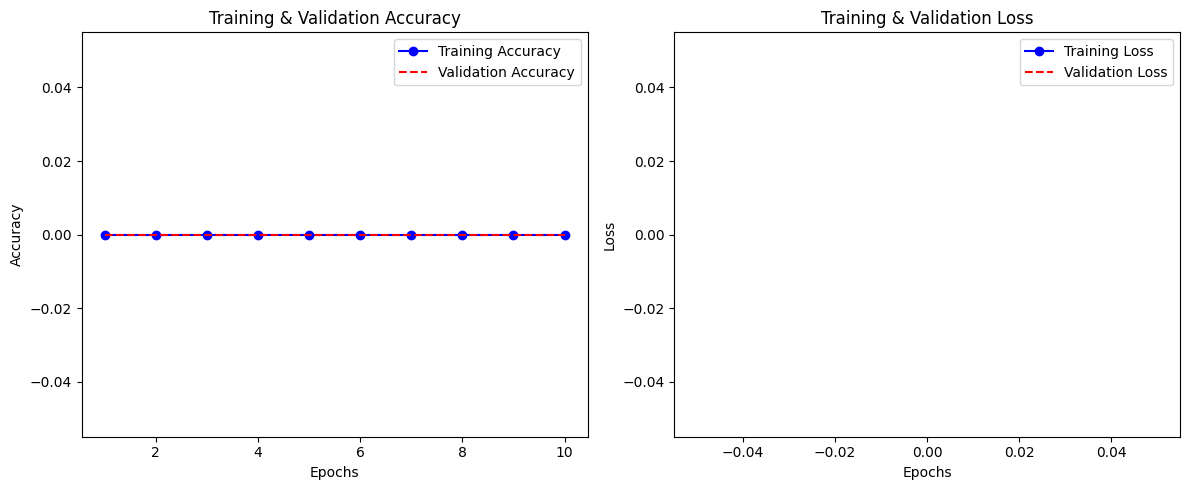

In [43]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Vẽ Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r--', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r--', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# cell: load model + tokenizer
from tensorflow.keras.models import load_model
import pickle
import os

MODEL_PATH = os.path.expanduser("../models/sqli_lstm_attention.h5")
TOKENIZER_PATH = os.path.expanduser("../models/tokenizer.pkl")

# Nếu có custom attention class, import và chuyển vào custom_objects:
# from my_layers import AttentionLayer
# model = load_model(MODEL_PATH, custom_objects={'AttentionLayer': AttentionLayer})

model = load_model(MODEL_PATH)
with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

print("✅ Loaded model:", MODEL_PATH)
print("✅ Loaded tokenizer:", TOKENIZER_PATH)


✅ Loaded model: ../models/sqli_lstm_attention.h5
✅ Loaded tokenizer: ../models/tokenizer.pkl


In [19]:
from tensorflow.keras.models import load_model
import pickle

# Load model và tokenizer đã lưu
model = load_model("../models/sqli_lstm_attention.h5")
with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("✅ Model và tokenizer loaded!")


✅ Model và tokenizer loaded!


In [13]:
# 🧠 Lưu model và tokenizer để dùng lại sau này
model.save("../models/sqli_lstm_attention.h5")

import pickle
with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Model và tokenizer đã được lưu trong thư mục /models")



✅ Model và tokenizer đã được lưu trong thư mục /models


In [15]:
# Cell: Load model/tokenizer, prepare data, evaluate, test queries
import os, pickle
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix, classification_report

MODEL_PATH = os.path.expanduser("../models/sqli_lstm_attention.h5")
TOKENIZER_PATH = os.path.expanduser("../models/tokenizer.pkl")
DATA_PATH = os.path.expanduser("../dataset/sample_sqli.csv")   # sửa nếu cần

# --- 1) Load model + tokenizer
try:
    model = load_model(MODEL_PATH)
except Exception as e:
    raise RuntimeError(f"Không load được model từ {MODEL_PATH}: {e}")

try:
    with open(TOKENIZER_PATH, "rb") as f:
        tokenizer = pickle.load(f)
except Exception as e:
    raise RuntimeError(f"Không load được tokenizer từ {TOKENIZER_PATH}: {e}")

print("✅ Loaded model & tokenizer.")
print("Model summary:")
model.summary()

# --- 2) Lấy maxlen từ model input (nếu có)
try:
    # model.input_shape thường là (None, maxlen)
    input_shape = model.input_shape
    if isinstance(input_shape, (list,tuple)) and len(input_shape) >= 2:
        MAXLEN = input_shape[1] if input_shape[1] is not None else 50
    else:
        MAXLEN = 50
except Exception:
    MAXLEN = 50

print("Using MAXLEN =", MAXLEN)

# --- 3) Read dataset (if có) và chuẩn hoá
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # mong file có 2 cột: query, label (label dạng 'benign' hoặc 'sqli' hoặc 0/1)
    if 'query' not in df.columns or 'label' not in df.columns:
        raise RuntimeError("CSV phải có 2 cột: 'query' và 'label'")
    texts = df['query'].astype(str).tolist()
    raw_labels = df['label'].tolist()

    # map nhãn text sang 0/1 nếu cần
    if all(isinstance(x, str) for x in raw_labels):
        lbl_map = {}
        uniq = sorted(set(raw_labels))
        # cố gắng map 'benign'->0, 'sqli'->1 nếu có
        if 'benign' in uniq and 'sqli' in uniq:
            lbl_map = {'benign':0, 'sqli':1}
        else:
            # nếu khác, map theo thứ tự xuất hiện
            lbl_map = {v:i for i,v in enumerate(uniq)}
        y = np.array([lbl_map[x] for x in raw_labels])
    else:
        y = np.array(raw_labels).astype(int)

    # tokenize + pad
    seqs = tokenizer.texts_to_sequences(texts)
    X = pad_sequences(seqs, maxlen=MAXLEN, padding='post', truncating='post')
    print("Dataset loaded:", df.shape)
else:
    print("⚠️ Không tìm thấy dataset tại", DATA_PATH)
    X = None
    y = None
    df = None

# --- 4) Evaluate trên toàn bộ dataset nếu có
if X is not None and len(X)>0 and y is not None:
    preds_proba = model.predict(X, verbose=0).reshape(-1)
    y_pred = (preds_proba >= 0.5).astype(int)

    print("\nConfusion matrix:")
    print(confusion_matrix(y, y_pred))

    print("\nClassification report:")
    print(classification_report(y, y_pred, target_names=['benign','sqli']))

    # Lưu kết quả vào csv trong thư mục models
    out_df = df.copy()
    out_df['pred_proba'] = preds_proba
    out_df['pred_label'] = y_pred
    out_csv = os.path.expanduser("../models/predictions.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"\n✅ Predictions saved to {out_csv}")
else:
    print("Skipping evaluation because dataset not available.")

# --- 5) Test vài câu sample thủ công
def predict_query(q):
    seq = tokenizer.texts_to_sequences([str(q)])
    seq = pad_sequences(seq, maxlen=MAXLEN, padding='post', truncating='post')
    p = float(model.predict(seq, verbose=0)[0][0])
    label = 'sqli' if p>=0.5 else 'benign'
    return p, label

samples = [
    "SELECT * FROM users WHERE id=1",
    "1 OR 1=1 --",
    "'; DROP TABLE users; --",
    "SELECT name FROM accounts WHERE email='a@b.com'"
]

print("\nSample predictions:")
for s in samples:
    p,label = predict_query(s)
    print(f"  [{label:6}] {p:.4f}  —  {s}")

print("\n✅ Finished. Nếu muốn, sửa PATHs ở đầu cell và chạy lại.")


✅ Loaded model & tokenizer.
Model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 64)    │    320,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 50, 64)    │     33,024 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 50, 64)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 353,091 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Using MAXLEN = 50
Dataset loaded: (4, 2)

Confusion matrix:
[[2 0]
 [2 0]]

Classification report:
              precision    recall  f1-score   support

      benign       0.50      1.00      0.67         2
        sqli       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


✅ Predictions saved to ../models/predictions.csv

Sample predictions:


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

  [benign] nan  —  SELECT * FROM users WHERE id=1
  [benign] nan  —  1 OR 1=1 --
  [benign] nan  —  '; DROP TABLE users; --
  [benign] nan  —  SELECT name FROM accounts WHERE email='a@b.com'

✅ Finished. Nếu muốn, sửa PATHs ở đầu cell và chạy lại.


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = (model.predict(X) >= 0.5).astype(int).flatten()

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['benign', 'sqli']))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Confusion Matrix:
[[2 0]
 [2 0]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.50      1.00      0.67         2
        sqli       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

test_query = ["SELECT * FROM users WHERE id=1"]  # câu hợp lệ
test_query2 = ["1 OR 1=1; --"]                   # câu tấn công SQLi

MAXLEN = 50  # hoặc giá trị bạn dùng khi train
seq1 = pad_sequences(tokenizer.texts_to_sequences(test_query), maxlen=MAXLEN, padding='post')
seq2 = pad_sequences(tokenizer.texts_to_sequences(test_query2), maxlen=MAXLEN, padding='post')

pred1 = model.predict(seq1)[0][0]
pred2 = model.predict(seq2)[0][0]

print(f"'{test_query[0]}' → {'SQL Injection' if pred1 >= 0.5 else 'Benign'} ({pred1:.4f})")
print(f"'{test_query2[0]}' → {'SQL Injection' if pred2 >= 0.5 else 'Benign'} ({pred2:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
'SELECT * FROM users WHERE id=1' → Benign (nan)
'1 OR 1=1; --' → Benign (nan)


In [21]:
print("Tokenizer word_index size:", len(tokenizer.word_index))
print("Model input shape:", model.input_shape)


Tokenizer word_index size: 12
Model input shape: (None, 50)


In [22]:
print("Vocab:", tokenizer.word_index)
print("Test 1:", tokenizer.texts_to_sequences(["SELECT * FROM users WHERE id=1"]))
print("Test 2:", tokenizer.texts_to_sequences(["1 OR 1=1; --"]))


Vocab: {'<OOV>': 1, '1': 2, 'select': 3, 'from': 4, 'users': 5, 'id': 6, "'": 7, 'drop': 8, 'table': 9, 'products': 10, 'where': 11, 'or': 12}
Test 1: [[3, 4, 5, 11, 6, 2]]
Test 2: [[2, 12, 2, 2]]


In [23]:
model.save("../models/sqli_lstm_attention.keras")


In [24]:
from tensorflow.keras.models import load_model
model = load_model("../models/sqli_lstm_attention.keras")


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
test_query = ["select * from users where id=1"]
test_query2 = ["1 or 1=1 --"]

seq1 = pad_sequences(tokenizer.texts_to_sequences(test_query), maxlen=50, padding='post')
seq2 = pad_sequences(tokenizer.texts_to_sequences(test_query2), maxlen=50, padding='post')

pred1 = float(model.predict(seq1)[0][0])
pred2 = float(model.predict(seq2)[0][0])

print(f"'{test_query[0]}' → {'SQL Injection' if pred1>=0.5 else 'Benign'} ({pred1:.4f})")
print(f"'{test_query2[0]}' → {'SQL Injection' if pred2>=0.5 else 'Benign'} ({pred2:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
'select * from users where id=1' → Benign (nan)
'1 or 1=1 --' → Benign (nan)


In [26]:
import numpy as np

for layer in model.layers:
    w = layer.get_weights()
    if w:
        for arr in w:
            if np.isnan(arr).any():
                print("⚠️ NaN detected in layer:", layer.name)


⚠️ NaN detected in layer: embedding_1
⚠️ NaN detected in layer: lstm_1
⚠️ NaN detected in layer: lstm_1
⚠️ NaN detected in layer: lstm_1
⚠️ NaN detected in layer: dense_1
⚠️ NaN detected in layer: dense_1


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# Load model/tokenizer mới
model = load_model("../models/sqli_lstm_attention.keras")
with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

test_query = ["select * from users where id=1"]
test_query2 = ["1 or 1=1 --"]

seq1 = pad_sequences(tokenizer.texts_to_sequences(test_query), maxlen=50, padding='post')
seq2 = pad_sequences(tokenizer.texts_to_sequences(test_query2), maxlen=50, padding='post')

pred1 = float(model.predict(seq1)[0][0])
pred2 = float(model.predict(seq2)[0][0])

print(f"'{test_query[0]}' → {'SQL Injection' if pred1>=0.5 else 'Benign'} ({pred1:.4f})")
print(f"'{test_query2[0]}' → {'SQL Injection' if pred2>=0.5 else 'Benign'} ({pred2:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
'select * from users where id=1' → Benign (nan)
'1 or 1=1 --' → Benign (nan)


In [31]:
from train_clean import CustomAttention
model = load_model("../models/sqli_lstm_attention.keras",
                   custom_objects={"CustomAttention": CustomAttention})


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'attention' (of type CustomAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    128,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │        114 │ lstm[0][0],       │
│ (CustomAttention)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ attention[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 161,203 (629.70 KB)

 Trainable params: 161,203 (629.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.8333 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6829 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.6768 - val_accuracy: 0.5000 - val_loss: 0.6964
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.6688 - val_accuracy: 0.5000 - val_loss: 0.6987
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.6571 - val_accuracy: 0.5000 - val_loss: 0.7023
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.6440 - val_accuracy: 0.5000 - val_loss: 0.7076
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.6261 - val_accuracy: 0.0000e+00 - val_loss: 0.7162
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6026 - val_accuracy: 0.0000e+00 - val_loss

In [32]:
from tensorflow.keras.models import load_model
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load model + custom layer
from train_clean import CustomAttention
model = load_model("../models/sqli_lstm_attention.keras",
                   custom_objects={"CustomAttention": CustomAttention})

with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

test_query = ["select * from users where id=1"]
test_query2 = ["1 or 1=1 --"]

seq1 = pad_sequences(tokenizer.texts_to_sequences(test_query), maxlen=50, padding='post')
seq2 = pad_sequences(tokenizer.texts_to_sequences(test_query2), maxlen=50, padding='post')

pred1 = float(model.predict(seq1)[0][0])
pred2 = float(model.predict(seq2)[0][0])

print(f"'{test_query[0]}' → {'SQL Injection' if pred1>=0.5 else 'Benign'} ({pred1:.4f})")
print(f"'{test_query2[0]}' → {'SQL Injection' if pred2>=0.5 else 'Benign'} ({pred2:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
'select * from users where id=1' → Benign (0.4281)
'1 or 1=1 --' → SQL Injection (0.6148)


In [62]:
# Cell 1 — Config & environment
import sys
from pathlib import Path
import os

print("Python:", sys.version.split()[0])
print("cwd:", os.getcwd())

# Tự động phát hiện project root (chứa train_clean.py hoặc models/)
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd.parent.parent]
project_root = None
for c in candidates:
    if (c / "train_clean.py").exists() or (c / "models").exists() or (c / "test_datasets.py").exists():
        project_root = c.resolve()
        break
if project_root is None:
    # fallback: assume parent
    project_root = cwd.parent.resolve()
    print("⚠️ Không tìm thấy dấu hiệu project root. Dùng parent:", project_root)

# Thêm vào sys.path để import modules từ project root
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print("Project root:", project_root_str)
# Thiết lập các path mặc định (dùng trong các cell sau)
DATASET_DIR = str(project_root / "dataset")
MODEL_DIR = str(project_root / "models")
print("DATASET_DIR:", DATASET_DIR)
print("MODEL_DIR:", MODEL_DIR)


Python: 3.11.14
cwd: /Users/thanhsang/SQLi_Detection_Project/notebooks
Project root: /Users/thanhsang/SQLi_Detection_Project/notebooks
DATASET_DIR: /Users/thanhsang/SQLi_Detection_Project/notebooks/dataset
MODEL_DIR: /Users/thanhsang/SQLi_Detection_Project/notebooks/models


In [64]:
# Paste thay phần detect project root cũ
from pathlib import Path
import sys, os

cwd = Path.cwd()
print("cwd:", cwd)

# tìm folder dataset ở cây thư mục lên phía trên (tối đa 4 cấp)
found = None
for up in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent, cwd.parent.parent.parent.parent]:
    candidate = up / "dataset"
    if candidate.exists() and candidate.is_dir():
        found = candidate.resolve()
        break

if found is None:
    # nếu không tìm thấy, fallback về project root parent (1 cấp lên)
    print("⚠️ Không tìm thấy folder 'dataset' trong 4 cấp cha. Hãy chắc bạn đã tạo folder dataset ở project root.")
    DATASET_DIR = str((cwd.parent / "dataset").resolve())
else:
    DATASET_DIR = str(found)

print("Using DATASET_DIR =", DATASET_DIR)

# đảm bảo DATASET_DIR có tồn tại, nếu không thì in hướng dẫn tạo
if not os.path.isdir(DATASET_DIR):
    print("‼️ Lưu ý: folder dataset chưa tồn tại. Bạn có thể tạo bằng:")
    print(f"   mkdir -p {DATASET_DIR}")
else:
    print("Contents:", sorted(os.listdir(DATASET_DIR))[:30])


cwd: /Users/thanhsang/SQLi_Detection_Project/notebooks
Using DATASET_DIR = /Users/thanhsang/SQLi_Detection_Project/dataset
Contents: ['sample_sqli.csv', 'test_dataset_1.csv', 'test_dataset_1.csv.bak', 'train_augmented.csv', 'train_augmented_v2.csv']


In [65]:
# Tạo train_augmented.csv vào DATASET_DIR (sử dụng DATASET_DIR đã detect ở Cell 1)
import random, os, csv
from pathlib import Path
import pandas as pd

# config: thay N_SAMPLES_PER_CLASS nếu muốn (ví dụ 500)
N_SAMPLES_PER_CLASS = 500

DATASET_DIR = Path(DATASET_DIR)  # dùng biến đã detect
#OUT_PATH = DATASET_DIR / "train_augmented.csv"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = Path(DATASET_DIR) / "train_augmented_v2.csv"


random.seed(42)

benign_templates = [
    "SELECT * FROM {table} WHERE id={id}",
    "SELECT {cols} FROM {table} WHERE {col}='{val}'",
    "INSERT INTO {table} ({cols}) VALUES ({vals})",
    "UPDATE {table} SET {col}='{val}' WHERE id={id}",
    "DELETE FROM {table} WHERE created_at < '{date}'",
    "SELECT COUNT(*) FROM {table} WHERE status='{status}'",
    "SELECT name, email FROM {table} WHERE active=1",
    "SELECT * FROM orders WHERE user_id={id} ORDER BY created_at DESC LIMIT 10",
    "SELECT price FROM products WHERE sku='{sku}'",
    "SELECT id FROM users WHERE email LIKE '%@{domain}'"
]

sqli_templates = [
    "1 OR 1=1 --",
    "' OR '1'='1",
    "\" OR \"1\"=\"1",
    "'; DROP TABLE {table}; --",
    "\"; DROP TABLE {table}; --",
    "' OR 1=1; --",
    "' OR 'a'='a'; --",
    "\" OR \"a\"=\"a\"; --",
    "admin' --",
    "admin' #",
    "' UNION SELECT {cols} FROM {table} --",
    "' UNION SELECT username, password FROM {table} --",
    "'; EXEC xp_cmdshell('dir'); --",
    "'; SELECT * FROM information_schema.tables; --",
    "' OR sleep(5)--",
    "' OR pg_sleep(5)--"
]

tables = ["users", "products", "orders", "accounts", "sessions", "comments"]
cols_pool = ["id", "name", "email", "password", "username", "address", "price", "status"]
domains = ["example.com", "gmail.com", "hotmail.com"]
statuses = ["active","inactive","pending"]

def gen_benign():
    t = random.choice(benign_templates)
    table = random.choice(tables)
    cols = ", ".join(random.sample(cols_pool, k=random.randint(1,3)))
    col = random.choice(cols_pool)
    val = random.choice(["admin", "john", "alice", "bob", "a@b.com", "test"])
    idn = random.randint(1,200)
    vals = ", ".join([f"'{random.choice(['x','y','z','1','2'])}'" for _ in range(cols.count(",")+1 if "," in cols else 1)])
    sku = f"SKU{random.randint(1000,9999)}"
    date = f"2023-{random.randint(1,12):02d}-{random.randint(1,28):02d}"
    status = random.choice(statuses)
    domain = random.choice(domains)
    return t.format(table=table, cols=cols, col=col, val=val, id=idn, vals=vals, sku=sku, date=date, status=status, domain=domain)

def gen_sqli():
    t = random.choice(sqli_templates)
    table = random.choice(tables)
    cols = ", ".join(random.sample(cols_pool, k=random.randint(1,2)))
    return t.format(table=table, cols=cols)

rows = []
for _ in range(N_SAMPLES_PER_CLASS):
    rows.append({"query": gen_benign(), "label": "benign"})
for _ in range(N_SAMPLES_PER_CLASS):
    rows.append({"query": gen_sqli(), "label": "sqli"})
random.shuffle(rows)

# write CSV
with open(OUT_PATH, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["query","label"])
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print("✅ Wrote:", OUT_PATH, " samples:", len(rows))
print("Preview 6 random rows:")
display(pd.read_csv(OUT_PATH).sample(6))


✅ Wrote: /Users/thanhsang/SQLi_Detection_Project/dataset/train_augmented_v2.csv  samples: 1000
Preview 6 random rows:


,query,label
521,SELECT * FROM orders WHERE user_id=153 ORDER B...,benign
737,' OR 1=1; --,sqli
740,SELECT COUNT(*) FROM orders WHERE status='pend...,benign
660,"SELECT name, email FROM orders WHERE active=1",benign
411,DELETE FROM accounts WHERE created_at < '2023-...,benign
678,admin' --,sqli


In [69]:
# Cell 2 — Kiểm tra dataset tồn tại, hiển thị sample
import os
import pandas as pd

print("Listing dataset dir:", DATASET_DIR)
if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(f"Không tìm thấy thư mục dataset: {DATASET_DIR}")

# show CSV files
csvs = sorted([f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")])
print("CSV files:", csvs)

# Nếu có file sample_sqli.csv thì hiển thị head, nếu không hiển thị một file test_*.csv đầu tiên
sample_path = os.path.join(DATASET_DIR, "sample_sqli.csv")
if not os.path.exists(sample_path):
    matches = [os.path.join(DATASET_DIR, f) for f in csvs if f.startswith("test_")]
    sample_path = matches[0] if matches else None

if sample_path:
    print("Preview:", sample_path)
    try:
        df = pd.read_csv(sample_path)
        display(df.head(10))
        print("Shape:", df.shape)
    except Exception as e:
        print("⚠️ pandas.read_csv lỗi:", e)
        print("Hãy chạy Cell 3 để sanitize CSV tự động.")
else:
    print("Không có CSV mẫu trong dataset/ để preview.")


Listing dataset dir: /Users/thanhsang/SQLi_Detection_Project/dataset
CSV files: ['sample_sqli.csv', 'test_dataset_1.csv', 'train_augmented.csv', 'train_augmented_v2.csv']
Preview: /Users/thanhsang/SQLi_Detection_Project/dataset/sample_sqli.csv


,query,label
0,SELECT * FROM users,benign
1,'; DROP TABLE users; --,sqli
2,SELECT id FROM products WHERE id=1,benign
3,1 OR 1=1,sqli


Shape: (4, 2)


In [73]:
# Cell 3 — Sanitize CSV: tạo backup .bak và bọc query bằng dấu kép nếu query chứa comma
import glob, shutil, csv

files = sorted(glob.glob(os.path.join(DATASET_DIR, "test_*.csv")))
if not files:
    print("Không tìm thấy test_*.csv trong", DATASET_DIR)
else:
    for path in files:
        bak = path + ".bak"
        if not os.path.exists(bak):
            shutil.copy2(path, bak)
            print("Backup:", bak)
        out_lines = []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            first = f.readline().rstrip("\n")
            has_header = ("query" in first.lower() and "label" in first.lower())
            if has_header:
                header = "query,label"
                # keep normalized header
            else:
                # treat first as data: will be processed below
                f.seek(0)
                header = "query,label"
            for i, raw in enumerate(f, start=1):
                s = raw.rstrip("\n")
                if not s.strip():
                    continue
                # try robust CSV parsing using csv.reader for quoted lines
                try:
                    parsed = next(csv.reader([s]))
                    if len(parsed) == 2:
                        q, lab = parsed[0].strip(), parsed[1].strip()
                        q = q.replace('"', '""')
                        out_lines.append(f'"{q}",{lab}')
                        continue
                except Exception:
                    pass
                # fallback: split by last comma
                parts = s.rsplit(",", 1)
                if len(parts) == 2:
                    q, lab = parts[0].strip(), parts[1].strip()
                    q = q.replace('"', '""')
                    out_lines.append(f'"{q}",{lab}')
                else:
                    # salvage: treat last token as label
                    pos = s.rfind(",")
                    if pos == -1:
                        q = s.strip().replace('"', '""')
                        lab = ""
                    else:
                        q = s[:pos].strip().replace('"', '""')
                        lab = s[pos+1:].strip()
                    out_lines.append(f'"{q}",{lab}')
        # write back with normalized header
        with open(path, "w", encoding="utf-8") as f:
            f.write(header + "\n")
            f.write("\n".join(out_lines) + "\n")
        print("Sanitized:", os.path.basename(path))
    print("✅ Đã sanitize xong tất cả test_*.csv (bản backup .bak được lưu).")


Sanitized: test_dataset_1.csv
✅ Đã sanitize xong tất cả test_*.csv (bản backup .bak được lưu).


In [75]:
# Cell 4 — Load sample dataset (dùng cho training demo). Sửa filename nếu cần.
import pandas as pd
import os
sample_fn = os.path.join(DATASET_DIR, "sample_sqli.csv")
if not os.path.exists(sample_fn):
    # fallback: try first test_*.csv
    import glob
    candidates = glob.glob(os.path.join(DATASET_DIR, "test_*.csv"))
    sample_fn = candidates[0] if candidates else None

if sample_fn is None:
    raise FileNotFoundError("Không tìm thấy sample_sqli.csv hoặc test_*.csv trong dataset/")
print("Using dataset:", sample_fn)
df = pd.read_csv(sample_fn)
# normalize column names
df.columns = [c.strip() for c in df.columns]
if "query" not in df.columns or "label" not in df.columns:
    raise RuntimeError("CSV cần 2 cột: 'query' và 'label'")

# map label text -> 0/1
df['label'] = df['label'].astype(str).str.lower().map(lambda x: 1 if x.strip() == 'sqli' else 0)
print("Loaded rows:", len(df))
display(df.head(8))


Using dataset: /Users/thanhsang/SQLi_Detection_Project/dataset/sample_sqli.csv
Loaded rows: 4


,query,label
0,SELECT * FROM users,0
1,'; DROP TABLE users; --,1
2,SELECT id FROM products WHERE id=1,0
3,1 OR 1=1,1


In [50]:
# Cell 5 — Tokenizer, sequences và padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

TEXT_COL = "query"
LABEL_COL = "label"
VOCAB_SIZE = 5000
MAXLEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df[TEXT_COL].astype(str))

sequences = tokenizer.texts_to_sequences(df[TEXT_COL].astype(str))
X = pad_sequences(sequences, maxlen=MAXLEN, padding='post', truncating='post')
y = np.array(df[LABEL_COL].astype(int))

print("Vocab size (word_index):", len(tokenizer.word_index))
print("X shape:", X.shape, "y shape:", y.shape)


Vocab size (word_index): 12
X shape: (4, 50) y shape: (4,)


In [51]:
# Cell 6 — Build model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index)+1)
embedding_dim = 64

inputs = Input(shape=(MAXLEN,), name="input_layer")
x = Embedding(vocab_size, embedding_dim, name="embedding")(inputs)
lstm_out = LSTM(64, return_sequences=True, name="lstm")(x)

# Keras Attention: query=key=value = lstm_out
attn_out = Attention(name="attention")([lstm_out, lstm_out])
pooled = GlobalAveragePooling1D(name="pool")(attn_out)

outputs = Dense(1, activation="sigmoid", name="output")(pooled)
model = Model(inputs, outputs, name="sqli_lstm_attn")
model.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sqli_lstm_attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │        832 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     33,024 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 64)    │          0 │ lstm[0][0],       │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool                │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ pool[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6667 - loss: 0.6874 - val_accuracy: 0.0000e+00 - val_loss: 0.7366
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6667 - loss: 0.6799 - val_accuracy: 0.0000e+00 - val_loss: 0.7646
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6667 - loss: 0.6726 - val_accuracy: 0.0000e+00 - val_loss: 0.7962
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6667 - loss: 0.6653 - val_accuracy: 0.0000e+00 - val_loss: 0.8328
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6667 - loss: 0.6580 - val_accuracy: 0.0000e+00 - val_loss: 0.8762
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6667 - loss: 0.6510 - val_accuracy: 0.0000e+00 - val_loss: 0.9289
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6667 - loss: 0.6444 - val_accuracy: 0.0000e+00 - val_loss: 0.9940
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6667 - loss: 0.6390 - val_acc

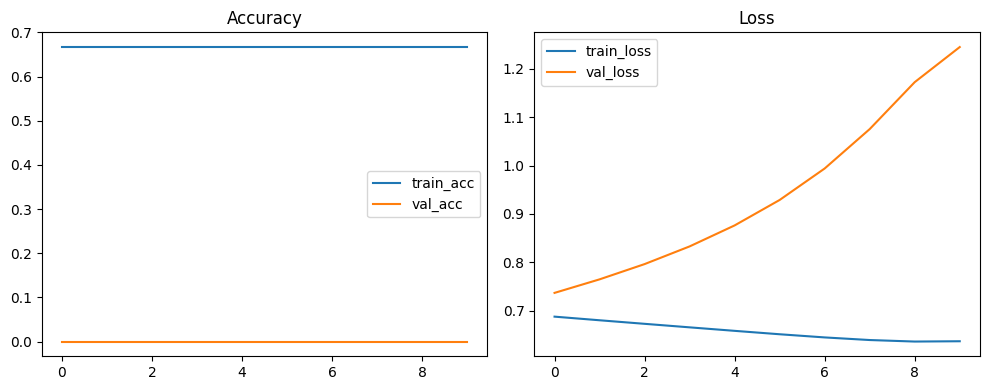

In [52]:
# Cell 7 — Train (demo)
import matplotlib.pyplot as plt

history = model.fit(
    X, y,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# plot short history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")
plt.tight_layout(); plt.show()


In [53]:
# Cell 8 — Save model & tokenizer
import pickle, os
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "sqli_lstm_attention.keras")
tokenizer_path = os.path.join(MODEL_DIR, "tokenizer.pkl")

model.save(model_path)
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

print("Saved model ->", model_path)
print("Saved tokenizer ->", tokenizer_path)


Saved model -> /Users/thanhsang/SQLi_Detection_Project/notebooks/models/sqli_lstm_attention.keras
Saved tokenizer -> /Users/thanhsang/SQLi_Detection_Project/notebooks/models/tokenizer.pkl


In [54]:
# Cell 9 — Load and evaluate
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

model_path = os.path.join(MODEL_DIR, "sqli_lstm_attention.keras")
tokenizer_path = os.path.join(MODEL_DIR, "tokenizer.pkl")

# if you used a custom layer, import and pass custom_objects here
# from train_clean import CustomAttention
# model = load_model(model_path, custom_objects={"CustomAttention": CustomAttention})
model = load_model(model_path)
with open(tokenizer_path, "rb") as f:
    tokenizer = pickle.load(f)

# prepare X,y from the df loaded in Cell 4
seqs = tokenizer.texts_to_sequences(df[TEXT_COL].astype(str))
X_eval = pad_sequences(seqs, maxlen=MAXLEN, padding='post')
y_eval = y

preds_proba = model.predict(X_eval, verbose=0).reshape(-1)
preds = (preds_proba >= 0.5).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_eval, preds))
print("\nClassification report:")
print(classification_report(y_eval, preds, target_names=["benign","sqli"]))

# save predictions
out = df.copy()
out["pred_proba"] = preds_proba
out["pred_label"] = preds
out_csv = os.path.join(MODEL_DIR, "predictions.csv")
out.to_csv(out_csv, index=False)
print("Saved predictions to", out_csv)


Confusion matrix:
[[2 0]
 [2 0]]

Classification report:
              precision    recall  f1-score   support

      benign       0.50      1.00      0.67         2
        sqli       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

Saved predictions to /Users/thanhsang/SQLi_Detection_Project/notebooks/models/predictions.csv


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [55]:
# Cell 10 — Predict single queries and debug info
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def predict_query(q, threshold=0.5):
    seq = tokenizer.texts_to_sequences([str(q)])
    seq = pad_sequences(seq, maxlen=MAXLEN, padding='post')
    p = float(model.predict(seq, verbose=0)[0][0])
    return p, ("sqli" if p >= threshold else "benign")

samples = [
    "SELECT * FROM users WHERE id=1",
    "1 OR 1=1 --",
    "'; DROP TABLE users; --",
    "search for red shoes"
]
for s in samples:
    p, lbl = predict_query(s)
    print(f"{lbl:6} {p:.4f}  —  {s}")

# Debug helpers
print("\nTokenizer size:", len(tokenizer.word_index))
print("Model input shape:", model.input_shape)
# quick NaN check
import math
for layer in model.layers:
    ws = layer.get_weights()
    if ws:
        for arr in ws:
            if np.isnan(arr).any():
                print("⚠️ NaN in layer", layer.name)
                break
print("Done.")


benign 0.2907  —  SELECT * FROM users WHERE id=1
benign 0.2878  —  1 OR 1=1 --
benign 0.2900  —  '; DROP TABLE users; --
benign 0.2877  —  search for red shoes

Tokenizer size: 12
Model input shape: (None, 50)
Done.


In [76]:
# === Cell: Train upgraded model (Embedding 128, LSTM 128, EarlyStopping, Checkpoint) ===
from pathlib import Path
import os, pickle, random
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, GlobalAveragePooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# === PATH CONFIG (tự động xác định thư mục dataset và models) ===
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if (cwd / "notebooks").exists() else cwd
DATA_DIR = PROJECT_ROOT.parent / "dataset"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train_augmented.csv"

# === HYPERPARAMETERS ===
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"
MAXLEN = 50
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 8
EPOCHS = 20
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# === LOAD TRAIN DATA ===
if not TRAIN_CSV.exists():
    raise FileNotFoundError(f"❌ Không tìm thấy {TRAIN_CSV}. Hãy chạy cell tạo dataset trước.")
df = pd.read_csv(TRAIN_CSV)
df['query'] = df['query'].astype(str)
df['label'] = df['label'].astype(str).str.lower().map(lambda x: 1 if x.strip() == 'sqli' else 0)

print(f"✅ Loaded {len(df)} samples from {TRAIN_CSV.name}")
print(df.head(3))

# === TOKENIZATION ===
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['query'])
sequences = tokenizer.texts_to_sequences(df['query'])
X = pad_sequences(sequences, maxlen=MAXLEN, padding='post', truncating='post')
y = np.array(df['label']).astype(int)

print("Vocabulary size:", len(tokenizer.word_index))
print("X shape:", X.shape, "| y shape:", y.shape)

# === MODEL ARCHITECTURE ===
inputs = Input(shape=(MAXLEN,), name="input")
x = Embedding(min(VOCAB_SIZE, len(tokenizer.word_index) + 1), EMBED_DIM, name="embedding")(inputs)
x = LSTM(LSTM_UNITS, return_sequences=True, name="lstm")(x)
att = Attention(name="attention")([x, x])
att = Dropout(0.2)(att)
pooled = GlobalAveragePooling1D(name="pool")(att)
dense = Dense(64, activation="relu", name="dense_relu")(pooled)
out = Dense(1, activation="sigmoid", name="output")(dense)

model = Model(inputs, out)
model.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# === CALLBACKS ===
ckpt_path = MODEL_DIR / "sqli_lstm_attention_best.keras"
es = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(str(ckpt_path), monitor="val_loss", save_best_only=True, verbose=1)
rl = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)

# === TRAIN MODEL ===
history = model.fit(
    X, y,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=[es, mc, rl],
    verbose=2
)

# === SAVE MODEL + TOKENIZER ===
final_model_path = MODEL_DIR / "sqli_lstm_attention.keras"
model.save(final_model_path)

with open(MODEL_DIR / "tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("\n✅ Saved final model to:", final_model_path)
print("✅ Best checkpoint:", ckpt_path)
print("📁 Tokenizer saved to:", MODEL_DIR / 'tokenizer.pkl')


✅ Loaded 1000 samples from train_augmented.csv
                                               query  label
0                    SELECT * FROM orders WHERE id=3      0
1                     '; EXEC xp_cmdshell('dir'); --      1
2  SELECT name, email, username FROM accounts WHE...      0
Vocabulary size: 271
X shape: (1000, 50) | y shape: (1000,)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 50)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │     34,816 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 128)   │    131,584 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 128)   │          0 │ lstm[0][0],       │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 128)   │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool                │ (None, 128)       │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu (Dense)  │ (None, 64)        │      8,256 │ pool[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dense_relu[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 174,721 (682.50 KB)

 Trainable params: 174,721 (682.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20

Epoch 1: val_loss improved from None to 0.00004, saving model to /Users/thanhsang/SQLi_Detection_Project/notebooks/models/sqli_lstm_attention_best.keras
100/100 - 7s - 66ms/step - accuracy: 0.7600 - loss: 0.4075 - val_accuracy: 1.0000 - val_loss: 3.5901e-05 - learning_rate: 0.0010
Epoch 2/20

Epoch 2: val_loss improved from 0.00004 to 0.00002, saving model to /Users/thanhsang/SQLi_Detection_Project/notebooks/models/sqli_lstm_attention_best.keras
100/100 - 3s - 28ms/step - accuracy: 1.0000 - loss: 2.6675e-05 - val_accuracy: 1.0000 - val_loss: 2.1752e-05 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: val_loss improved from 0.00002 to 0.00002, saving model to /Users/thanhsang/SQLi_Detection_Project/notebooks/models/sqli_lstm_attention_best.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
100/100 - 2s - 24ms/step - accuracy: 1.0000 - loss: 1.8438e-05 - val_accuracy: 1.0000 - val_loss: 1.5468e-05 - learning_rate: 0.0010
Epoch 4/20

Epoch 4: val_lo

In [78]:
# check_overlap.py — chạy trong notebook
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/Users/thanhsang/SQLi_Detection_Project/dataset/train_augmented.csv")
  # sửa path nếu cần
texts = df['query'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# tách bằng stratify (mô phỏng cách Keras validation_split tách: cuối cùng Keras tách theo đơn giản index)
train_texts, val_texts, train_idx, val_idx = train_test_split(
    texts, range(len(texts)),
    test_size=0.2, random_state=42, stratify=labels
)

# kiểm tra overlap:
overlap = set(train_texts).intersection(set(val_texts))
print("Total samples:", len(texts))
print("Train:", len(train_texts), "Val:", len(val_texts))
print("Overlap count:", len(overlap))
if len(overlap) > 0:
    print("Example overlap:", list(overlap)[:5])
else:
    print("No overlap between train/val (good).")


Total samples: 1000
Train: 800 Val: 200
Overlap count: 41
Example overlap: ["SELECT COUNT(*) FROM users WHERE status='active'", "admin' --", "' OR 'a'='a'; --", "' UNION SELECT username, password FROM comments --", "SELECT COUNT(*) FROM accounts WHERE status='pending'"]


Project root: /Users/thanhsang/SQLi_Detection_Project
DATA_DIR: /Users/thanhsang/SQLi_Detection_Project/dataset
MODEL_DIR: /Users/thanhsang/SQLi_Detection_Project/models
Original train rows: 1000
                                               query   label
0                    SELECT * FROM orders WHERE id=3  benign
1                     '; EXEC xp_cmdshell('dir'); --    sqli
2  SELECT name, email, username FROM accounts WHE...  benign
Backup saved: /Users/thanhsang/SQLi_Detection_Project/dataset/train_augmented.csv.bak
Deduped rows: 435 -> train_augmented_dedup.csv
test_dataset_1.csv overlap_count: 1
 -> Overlap list saved: /Users/thanhsang/SQLi_Detection_Project/dataset/overlap_test_dataset_1.csv.txt
Train_final rows: 348 Val_final rows: 87
X_train (348, 50) X_val (87, 50)
Vocab size (word_index): 241


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 50, 128)   │     30,976 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 50, 128)   │    131,584 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 50, 128)   │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ attention_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 170,881 (667.50 KB)

 Trainable params: 170,881 (667.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12

Epoch 1: val_loss improved from None to 0.39023, saving model to /Users/thanhsang/SQLi_Detection_Project/models/sqli_lstm_attention_explicit_best.keras
44/44 - 6s - 134ms/step - accuracy: 0.8678 - loss: 0.4325 - val_accuracy: 0.8736 - val_loss: 0.3902 - learning_rate: 0.0010
Epoch 2/12

Epoch 2: val_loss improved from 0.39023 to 0.37860, saving model to /Users/thanhsang/SQLi_Detection_Project/models/sqli_lstm_attention_explicit_best.keras
44/44 - 1s - 27ms/step - accuracy: 0.8707 - loss: 0.3937 - val_accuracy: 0.8736 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 3/12

Epoch 3: val_loss improved from 0.37860 to 0.36907, saving model to /Users/thanhsang/SQLi_Detection_Project/models/sqli_lstm_attention_explicit_best.keras
44/44 - 1s - 27ms/step - accuracy: 0.8707 - loss: 0.3866 - val_accuracy: 0.8736 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 4/12

Epoch 4: val_loss improved from 0.36907 to 0.05709, saving model to /Users/thanhsang/SQLi_Detection_Project/models/sqli_

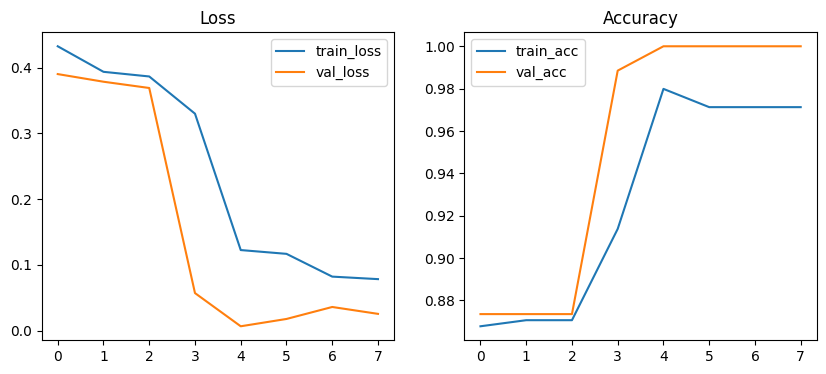


=== EVALUATE on test_*.csv ===

-- test_dataset_1.csv --
samples: 5
confusion_matrix:
               precision    recall  f1-score   support

      benign       1.00      0.50      0.67         2
        sqli       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

raw confusion matrix:
 [[1 1]
 [0 3]]

PIPELINE DONE. Check models in: /Users/thanhsang/SQLi_Detection_Project/models
train_final.csv, val_final.csv, train_augmented_dedup.csv located in /Users/thanhsang/SQLi_Detection_Project/dataset


In [79]:
#train lại 
# === PIPELINE: dedupe -> split -> train explicit -> eval on tests ===
# Copy/paste & run this single cell in your notebook (run Cell1 first so DATASET_DIR is set)
from pathlib import Path
import os, shutil, pickle
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# TF imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, GlobalAveragePooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ---------- PATH detection ----------
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = Path(PROJECT_ROOT) / "dataset"
MODEL_DIR = Path(PROJECT_ROOT) / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

# ---------- PARAMETERS ----------
TRAIN_SRC = DATA_DIR / "train_augmented.csv"     # input created earlier
DEDUPE_OUT = DATA_DIR / "train_augmented_dedup.csv"
TRAIN_FINAL = DATA_DIR / "train_final.csv"
VAL_FINAL = DATA_DIR / "val_final.csv"

VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"
MAXLEN = 50
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 8
EPOCHS = 12
RANDOM_SEED = 42
VALIDATION_SIZE = 0.2

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ---------- 1) Sanity: file exists ----------
if not TRAIN_SRC.exists():
    raise FileNotFoundError(f"Missing train file: {TRAIN_SRC}. Run dataset generation cell first.")

df = pd.read_csv(TRAIN_SRC)
print("Original train rows:", len(df))
print(df.head(3))

# ---------- 2) Deduplicate (exact query duplicates) ----------
bak = TRAIN_SRC.with_suffix(".csv.bak")
if not bak.exists():
    shutil.copy2(TRAIN_SRC, bak)
    print("Backup saved:", bak)

df_dedup = df.drop_duplicates(subset=['query'], keep='first').reset_index(drop=True)
df_dedup.to_csv(DEDUPE_OUT, index=False)
print("Deduped rows:", len(df_dedup), "->", DEDUPE_OUT.name)

# ---------- 3) Check overlap with test_*.csv (report) ----------
test_files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("test_") and f.endswith(".csv")])
for tfn in test_files:
    tdf = pd.read_csv(DATA_DIR / tfn)
    overlap = set(df_dedup['query']).intersection(set(tdf['query'].astype(str)))
    print(f"{tfn} overlap_count:", len(overlap))
    if len(overlap)>0:
        (DATA_DIR / f"overlap_{tfn}.txt").write_text("\n".join(list(overlap)))
        print(" -> Overlap list saved:", DATA_DIR / f"overlap_{tfn}.txt")

# ---------- 4) Stratified split (train_final / val_final) ----------
df_dedup['label_num'] = df_dedup['label'].astype(str).str.lower().map(lambda x: 1 if x.strip()=='sqli' else 0)
df_shuf = df_dedup.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
train_df, val_df = train_test_split(df_shuf, test_size=VALIDATION_SIZE, random_state=RANDOM_SEED, stratify=df_shuf['label_num'])
train_df.drop(columns=['label_num']).to_csv(TRAIN_FINAL, index=False)
val_df.drop(columns=['label_num']).to_csv(VAL_FINAL, index=False)
print("Train_final rows:", len(train_df), "Val_final rows:", len(val_df))

# ---------- 5) Tokenize (fit only on train) ----------
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['query'].astype(str))
X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['query'].astype(str)), maxlen=MAXLEN, padding='post')
y_train = np.array(train_df['label'].astype(str).str.lower().map(lambda x:1 if x=='sqli' else 0))
X_val = pad_sequences(tokenizer.texts_to_sequences(val_df['query'].astype(str)), maxlen=MAXLEN, padding='post')
y_val = np.array(val_df['label'].astype(str).str.lower().map(lambda x:1 if x=='sqli' else 0))
print("X_train", X_train.shape, "X_val", X_val.shape)
print("Vocab size (word_index):", len(tokenizer.word_index))

# ---------- 6) Build model ----------
inputs = Input(shape=(MAXLEN,))
x = Embedding(min(VOCAB_SIZE, len(tokenizer.word_index)+1), EMBED_DIM)(inputs)
x = LSTM(LSTM_UNITS, return_sequences=True)(x)
att = Attention()([x,x])
att = Dropout(0.2)(att)
pooled = GlobalAveragePooling1D()(att)
dense = Dense(64, activation='relu')(pooled)
out = Dense(1, activation='sigmoid')(dense)
model = Model(inputs, out)
model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------- 7) Callbacks & train ----------
ckpt = MODEL_DIR / "sqli_lstm_attention_explicit_best.keras"
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(str(ckpt), monitor='val_loss', save_best_only=True, verbose=1)
rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val,y_val),
                    callbacks=[es,mc,rl], verbose=2)

# save final and tokenizer
final_model_path = MODEL_DIR / "sqli_lstm_attention_explicit.keras"
model.save(final_model_path)
with open(MODEL_DIR / "tokenizer_explicit.pkl","wb") as f:
    pickle.dump(tokenizer, f)
print("Saved model:", final_model_path)
print("Saved tokenizer:", MODEL_DIR / "tokenizer_explicit.pkl")

# ---------- 8) Plot history ----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='train_loss'); plt.plot(history.history['val_loss'], label='val_loss'); plt.legend(); plt.title('Loss')
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='train_acc'); plt.plot(history.history['val_accuracy'], label='val_acc'); plt.legend(); plt.title('Accuracy')
plt.show()

# ---------- 9) Evaluate on test_*.csv ----------
print("\n=== EVALUATE on test_*.csv ===")
tokenizer_loaded = tokenizer  # same
for tfn in test_files:
    path = DATA_DIR / tfn
    tdf = pd.read_csv(path)
    X_test = pad_sequences(tokenizer_loaded.texts_to_sequences(tdf['query'].astype(str)), maxlen=MAXLEN, padding='post')
    y_test = np.array(tdf['label'].astype(str).str.lower().map(lambda x:1 if x=='sqli' else 0))
    y_prob = model.predict(X_test, verbose=0).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n-- {tfn} --")
    print("samples:", len(tdf))
    print("confusion_matrix:\n", classification_report(y_test, y_pred, target_names=['benign','sqli']))
    print("raw confusion matrix:\n", confusion_matrix(y_test, y_pred))

# ---------- 10) Summary ----------
print("\nPIPELINE DONE. Check models in:", MODEL_DIR)
print("train_final.csv, val_final.csv, train_augmented_dedup.csv located in", DATA_DIR)


In [3]:
# export_savedmodel_auto.py
from pathlib import Path
import tensorflow as tf
import sys

MODEL_DIR = Path("models")
candidates = sorted(MODEL_DIR.glob("*.keras"))
if not candidates:
    print("❌ Không tìm thấy file .keras trong thư mục models/.")
    sys.exit(1)

src = candidates[0]   # chọn file .keras đầu tiên (đã sort)
print("✅ Sử dụng file model:", src)

outdir = MODEL_DIR / "export" / "sqli" / "1"
outdir.mkdir(parents=True, exist_ok=True)

try:
    model = tf.keras.models.load_model(str(src))
except Exception as e:
    print("❌ Lỗi khi load model:", e)
    sys.exit(2)

tf.saved_model.save(model, str(outdir))
print("✅ SavedModel exported to:", outdir)
print("Contents:")
for p in outdir.rglob('*'):
    print(" -", p.relative_to(outdir))


✅ Sử dụng file model: models/sqli_lstm_attention.keras
INFO:tensorflow:Assets written to: models/export/sqli/1/assets


INFO:tensorflow:Assets written to: models/export/sqli/1/assets


✅ SavedModel exported to: models/export/sqli/1
Contents:
 - fingerprint.pb
 - variables
 - saved_model.pb
 - assets
 - variables/variables.data-00000-of-00001
 - variables/variables.index


In [23]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

# ================================
# 1) CẤU HÌNH ĐƯỜNG DẪN
# ================================
DATA_DIR = "../dataset"
MODEL_OUT = "../models/multi_runs"
TOKENIZER_PATH = "../models/tokenizer.pkl"

os.makedirs(MODEL_OUT, exist_ok=True)

TRAIN_CSV = f"{DATA_DIR}/train_final_extended.csv"  # dùng dataset mở rộng
VAL_CSV   = f"{DATA_DIR}/val_final.csv"             # val giữ nguyên

# ================================
# 2) HÀM LOAD DATASET
# ================================
def load_dataset(csv_path):
    df = pd.read_csv(csv_path)
    df["label"] = df["label"].map({"benign": 0, "sqli": 1})
    return df["query"].tolist(), df["label"].to_numpy()

# ================================
# 3) LOAD TOKENIZER
# ================================
import pickle
with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

vocab_size = len(tokenizer.word_index) + 1
print("Tokenizer vocab size:", vocab_size)

# ================================
# 4) VECTOR HOÁ DỮ LIỆU
# ================================
from tensorflow.keras.preprocessing.sequence import pad_sequences

def vectorize(texts, maxlen=50):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")

# ================================
# 5) MODEL LSTM + ATTENTION
# ================================
def build_model(vocab_size, maxlen):
    inputs = layers.Input(shape=(maxlen,))
    x = layers.Embedding(vocab_size, 128)(inputs)
    x = layers.LSTM(128, return_sequences=True)(x)

    # Attention
    attention = layers.Dense(1, activation="tanh")(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation("softmax")(attention)
    attention = layers.RepeatVector(128)(attention)
    attention = layers.Permute([2, 1])(attention)

    x = layers.multiply([x, attention])
    x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ================================
# 6) CHẠY MULTI-TRAIN
# ================================
def run_multi(n_runs=5, maxlen=50, epochs=10, batch=64, plot_per_run=True):
    X_train_text, y_train = load_dataset(TRAIN_CSV)
    X_val_text, y_val = load_dataset(VAL_CSV)

    X_train = vectorize(X_train_text, maxlen)
    X_val = vectorize(X_val_text, maxlen)

    results = []

    for r in range(1, n_runs + 1):
        print("\n" + "=" * 70)
        print(f"🚀 RUN {r}/{n_runs}")
        print("=" * 70)

        tf.random.set_seed(42 + r)
        np.random.seed(42 + r)

        model = build_model(vocab_size, maxlen)
        out_path = f"{MODEL_OUT}/run_{r}.keras"

        callbacks = [
            EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
            ModelCheckpoint(out_path, monitor="val_loss", save_best_only=True)
        ]

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch,
            verbose=2
        )

        # 👉 VẼ BIỂU ĐỒ CHO RUN HIỆN TẠI
        if plot_per_run:
            plot_history(history, run_id=r)

        val_acc = max(history.history["val_accuracy"])
        val_loss = min(history.history["val_loss"])

        print(f"→ Best val_accuracy = {val_acc:.4f}")
        print(f"→ Best val_loss     = {val_loss:.4f}")
        print(f"→ Saved: {out_path}")

        results.append({
            "run": r,
            "best_val_acc": val_acc,
            "best_val_loss": val_loss,
            "model_path": out_path
        })

    df = pd.DataFrame(results)
    df.to_csv(f"{MODEL_OUT}/multi_run_results.csv", index=False)
    print("\n📌 Saved multi-run results at:", f"{MODEL_OUT}/multi_run_results.csv")
    return df


# ================================
# 7) THỰC THI
# ================================
print("🔥 Multi-training ready. Chạy lệnh sau để bắt đầu:")
print("results = run_multi(n_runs=5, maxlen=50, epochs=10, batch=64)")


Tokenizer vocab size: 29
🔥 Multi-training ready. Chạy lệnh sau để bắt đầu:
results = run_multi(n_runs=5, maxlen=50, epochs=10, batch=64)


In [24]:
import matplotlib.pyplot as plt

def plot_history(history, run_id=None):
    """Vẽ biểu đồ loss / accuracy cho 1 lần train."""
    train_loss = history.history.get("loss", [])
    val_loss   = history.history.get("val_loss", [])
    train_acc  = history.history.get("accuracy", [])
    val_acc    = history.history.get("val_accuracy", [])

    epochs = range(len(train_loss))

    title_suffix = f" (run {run_id})" if run_id is not None else ""

    plt.figure(figsize=(10, 4))

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, marker="o", label="train_loss")
    plt.plot(epochs, val_loss,   marker="o", linestyle="--", label="val_loss")
    plt.title("Loss" + title_suffix)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # --- Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, marker="o", label="train_acc")
    plt.plot(epochs, val_acc,   marker="o", linestyle="--", label="val_acc")
    plt.title("Accuracy" + title_suffix)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()



🚀 RUN 1/5
Epoch 1/10
484/484 - 21s - 43ms/step - accuracy: 0.9923 - loss: 0.0350 - val_accuracy: 0.8391 - val_loss: 0.8680
Epoch 2/10
484/484 - 16s - 33ms/step - accuracy: 0.9971 - loss: 0.0113 - val_accuracy: 0.9655 - val_loss: 0.2756
Epoch 3/10
484/484 - 15s - 31ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9655 - val_loss: 0.1916
Epoch 4/10
484/484 - 15s - 31ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9540 - val_loss: 0.1419
Epoch 5/10
484/484 - 15s - 31ms/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 0.9540 - val_loss: 0.0726
Epoch 6/10
484/484 - 15s - 31ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9080 - val_loss: 0.3976
Epoch 7/10
484/484 - 15s - 31ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9540 - val_loss: 0.1231
Epoch 8/10
484/484 - 15s - 32ms/step - accuracy: 0.9984 - loss: 0.0059 - val_accuracy: 0.9540 - val_loss: 0.0751
Epoch 9/10
484/484 - 15s - 32ms/step - accuracy: 0.9990 - loss: 0.0036 - val_accuracy

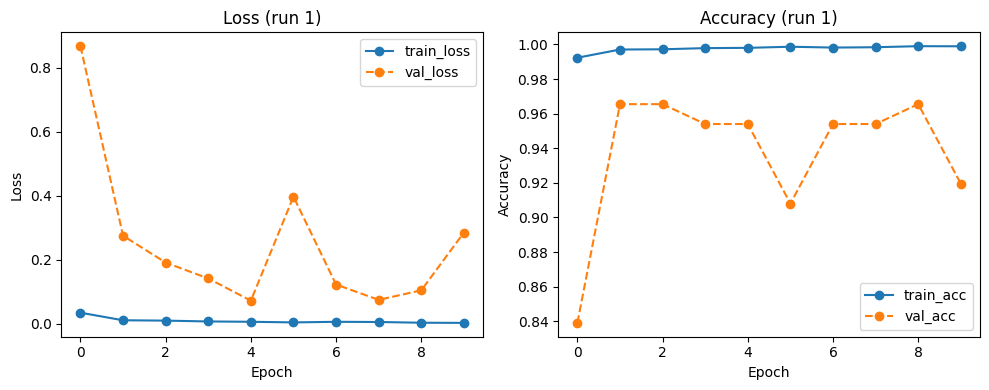

→ Best val_accuracy = 0.9655
→ Best val_loss     = 0.0726
→ Saved: ../models/multi_runs/run_1.keras

🚀 RUN 2/5
Epoch 1/10
484/484 - 18s - 36ms/step - accuracy: 0.9926 - loss: 0.0337 - val_accuracy: 0.9655 - val_loss: 0.2303
Epoch 2/10
484/484 - 15s - 31ms/step - accuracy: 0.9964 - loss: 0.0133 - val_accuracy: 0.9195 - val_loss: 0.2995
Epoch 3/10
484/484 - 15s - 31ms/step - accuracy: 0.9979 - loss: 0.0079 - val_accuracy: 0.8851 - val_loss: 0.2803
Epoch 4/10
484/484 - 16s - 32ms/step - accuracy: 0.9981 - loss: 0.0062 - val_accuracy: 0.8851 - val_loss: 0.2813
Epoch 5/10
484/484 - 15s - 32ms/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.8966 - val_loss: 0.2646
Epoch 6/10
484/484 - 15s - 32ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9195 - val_loss: 0.1478
Epoch 7/10
484/484 - 15s - 31ms/step - accuracy: 0.9985 - loss: 0.0042 - val_accuracy: 0.8966 - val_loss: 0.2078
Epoch 8/10
484/484 - 15s - 31ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 0.8966 - va

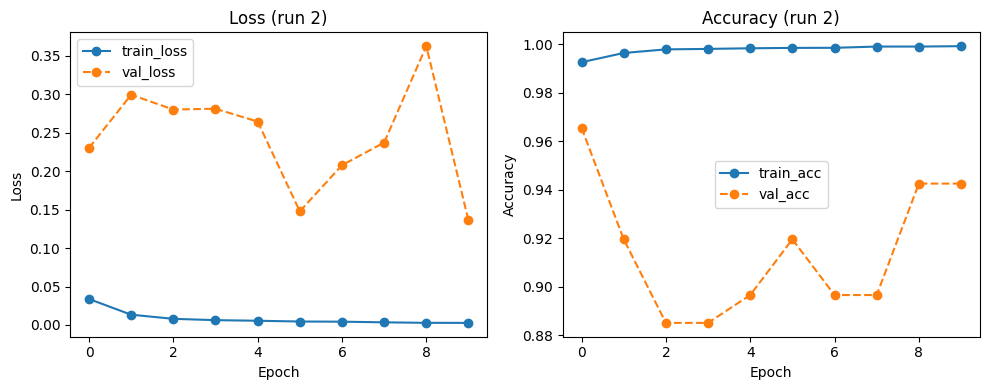

→ Best val_accuracy = 0.9655
→ Best val_loss     = 0.1360
→ Saved: ../models/multi_runs/run_2.keras

🚀 RUN 3/5
Epoch 1/10
484/484 - 17s - 36ms/step - accuracy: 0.9911 - loss: 0.0449 - val_accuracy: 0.7241 - val_loss: 0.7351
Epoch 2/10
484/484 - 15s - 31ms/step - accuracy: 0.9965 - loss: 0.0129 - val_accuracy: 0.9310 - val_loss: 0.2944
Epoch 3/10
484/484 - 15s - 31ms/step - accuracy: 0.9973 - loss: 0.0088 - val_accuracy: 0.8966 - val_loss: 0.3125
Epoch 4/10
484/484 - 15s - 31ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9310 - val_loss: 0.2202
Epoch 5/10
484/484 - 15s - 31ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.8851 - val_loss: 0.3455
Epoch 6/10
484/484 - 15s - 31ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.8506 - val_loss: 0.5100
Epoch 7/10
484/484 - 15s - 31ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.8851 - val_loss: 0.3706
Epoch 8/10
484/484 - 15s - 31ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.8966 - va

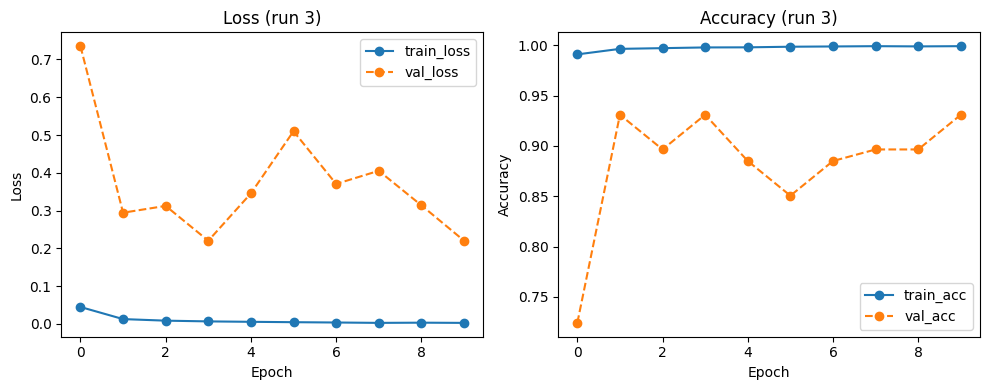

→ Best val_accuracy = 0.9310
→ Best val_loss     = 0.2202
→ Saved: ../models/multi_runs/run_3.keras

🚀 RUN 4/5
Epoch 1/10
484/484 - 18s - 36ms/step - accuracy: 0.9900 - loss: 0.0375 - val_accuracy: 0.5517 - val_loss: 0.8809
Epoch 2/10
484/484 - 15s - 31ms/step - accuracy: 0.9972 - loss: 0.0105 - val_accuracy: 0.8276 - val_loss: 0.6056
Epoch 3/10
484/484 - 16s - 33ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.8736 - val_loss: 0.3995
Epoch 4/10
484/484 - 16s - 33ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.8966 - val_loss: 0.2959
Epoch 5/10
484/484 - 17s - 35ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.8966 - val_loss: 0.1802
Epoch 6/10
484/484 - 15s - 32ms/step - accuracy: 0.9986 - loss: 0.0046 - val_accuracy: 0.9310 - val_loss: 0.2449
Epoch 7/10
484/484 - 15s - 31ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9310 - val_loss: 0.2037
Epoch 8/10
484/484 - 15s - 30ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9080 - va

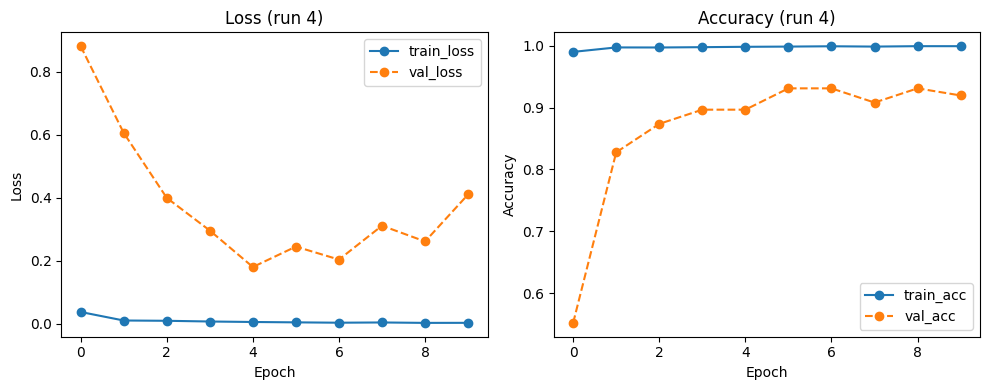

→ Best val_accuracy = 0.9310
→ Best val_loss     = 0.1802
→ Saved: ../models/multi_runs/run_4.keras

🚀 RUN 5/5
Epoch 1/10
484/484 - 17s - 36ms/step - accuracy: 0.9928 - loss: 0.0344 - val_accuracy: 0.9310 - val_loss: 0.3164
Epoch 2/10
484/484 - 15s - 31ms/step - accuracy: 0.9968 - loss: 0.0112 - val_accuracy: 0.8506 - val_loss: 0.3717
Epoch 3/10
484/484 - 15s - 31ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.8621 - val_loss: 0.3766
Epoch 4/10
484/484 - 15s - 31ms/step - accuracy: 0.9979 - loss: 0.0070 - val_accuracy: 0.8736 - val_loss: 0.2865
Epoch 5/10
484/484 - 15s - 31ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.8966 - val_loss: 0.2380
Epoch 6/10
484/484 - 15s - 32ms/step - accuracy: 0.9985 - loss: 0.0053 - val_accuracy: 0.9425 - val_loss: 0.1456
Epoch 7/10
484/484 - 15s - 31ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9310 - val_loss: 0.2228
Epoch 8/10
484/484 - 15s - 31ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.9770 - va

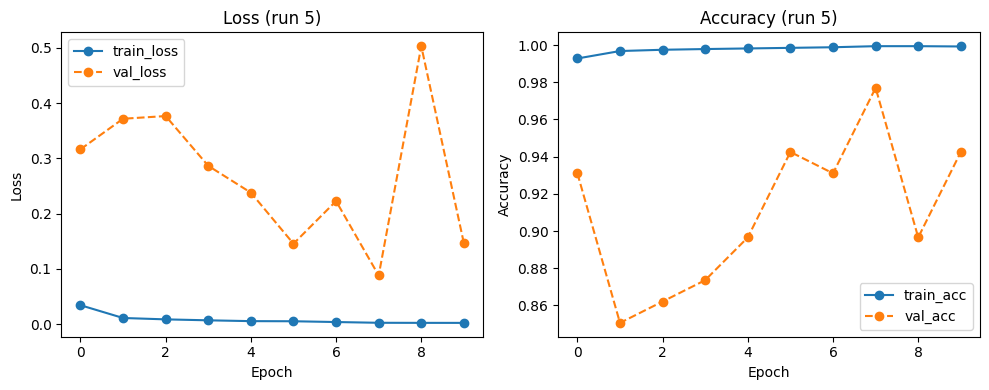

→ Best val_accuracy = 0.9770
→ Best val_loss     = 0.0881
→ Saved: ../models/multi_runs/run_5.keras

📌 Saved multi-run results at: ../models/multi_runs/multi_run_results.csv


,run,best_val_acc,best_val_loss,model_path
0,1,0.965517,0.072613,../models/multi_runs/run_1.keras
1,2,0.965517,0.135994,../models/multi_runs/run_2.keras
2,3,0.931035,0.220212,../models/multi_runs/run_3.keras
3,4,0.931035,0.180188,../models/multi_runs/run_4.keras
4,5,0.977012,0.088112,../models/multi_runs/run_5.keras


In [25]:
results = run_multi(n_runs=5, maxlen=50, epochs=10, batch=64, plot_per_run=True)
results


In [19]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../dataset")

df = pd.read_csv(DATA_DIR / "SQLiV3.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sentence    30904 non-null  object 
 1   Label       30664 non-null  object 
 2   Unnamed: 2  306 non-null    object 
 3   Unnamed: 3  9 non-null      float64
dtypes: float64(1), object(3)
memory usage: 966.3+ KB


In [20]:
df = pd.read_csv(DATA_DIR / "SQLiV3.csv")
df.head(20)


,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
5,select name from syscolumns where id = ...,1,NaN,NaN
6,select * from users where id = 1 +$+ or 1 =...,1,NaN,NaN
7,"1; ( load_file ( char ( 47,101,116,99,47...",1,NaN,NaN
8,select * from users where id = '1' or ||/1 ...,1,NaN,NaN
9,select * from users where id = '1' or \.<\ ...,1,NaN,NaN


In [21]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../dataset")

df = pd.read_csv(DATA_DIR / "SQLiV3.csv")

# Giữ lại cột cần thiết
df = df[["Sentence", "Label"]].copy()

# Đổi tên cho đúng format
df = df.rename(columns={"Sentence": "query", "Label": "label"})

# Loại bỏ NaN label (có 1 vài dòng bạn thấy Label = NaN)
df = df.dropna()

# Chuyển label 1 -> "sqli"
df["label"] = df["label"].apply(lambda x: "sqli")

df.head(), df.label.value_counts()


(                                               query label
 0                  " or pg_sleep  (  __TIME__  )  --  sqli
 2   AND 1  =  utl_inaddr.get_host_address   (    ...  sqli
 3   select * from users where id  =  '1' or @ @1 ...  sqli
 4   select * from users where id  =  1 or 1#"  ( ...  sqli
 5   select name from syscolumns where id   =     ...  sqli,
 label
 sqli    30649
 Name: count, dtype: int64)

In [22]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../dataset")

# 1. Đọc train cũ
train_old = pd.read_csv(DATA_DIR / "train_final.csv")
print("🔹 Train cũ:", train_old.shape)
print(train_old["label"].value_counts(), "\n")

# 2. Gộp train cũ + dataset Kaggle (df là biến bạn vừa xử lý ở trên)
train_new = pd.concat([train_old, df], ignore_index=True)

# (không bắt buộc) loại trùng query nếu có
train_new = train_new.drop_duplicates(subset="query")

# xáo trộn lại
train_new = train_new.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Lưu ra file mới
OUT_PATH = DATA_DIR / "train_final_extended.csv"
train_new.to_csv(OUT_PATH, index=False)

print("✅ Train mới:", train_new.shape)
print(train_new["label"].value_counts())
print("📁 Đã lưu tại:", OUT_PATH)


🔹 Train cũ: (348, 2)
label
benign    303
sqli       45
Name: count, dtype: int64 

✅ Train mới: (30973, 2)
label
sqli      30670
benign      303
Name: count, dtype: int64
📁 Đã lưu tại: ../dataset/train_final_extended.csv


In [28]:
import sys
from pathlib import Path

# Lấy thư mục gốc project:  notebook/.. = project root
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print("📁 Added to PYTHONPATH:", PROJECT_ROOT)


📁 Added to PYTHONPATH: /Users/thanhsang/SQLi_Detection_Project


In [29]:
from pathlib import Path
from tensorflow.keras.models import load_model
from train_multi import Attention   # import OK sau khi sửa sys.path

BEST_MODEL = "../models/multi_runs/sqli_lstm_attention_run5.keras"
EXPORT_DIR = "../models/exported"

Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)

model = load_model(
    BEST_MODEL,
    custom_objects={"Attention": Attention}
)

model.save(f"{EXPORT_DIR}/sqli_lstm_attention_updated.keras")
print("✅ Export done!")


/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/thanhsang/venv-sqli/lib/python3.11/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'attention' (of type Attention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


✅ Export done!


In [33]:
from pathlib import Path
import sys, pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==== 1. PROJECT ROOT (đi lên 1 cấp từ notebooks/) ====
PROJECT_ROOT = Path.cwd().parent
print("PROJECT_ROOT:", PROJECT_ROOT)

# ==== 2. Đường dẫn model + tokenizer ====
MODEL_PATH = PROJECT_ROOT / "models" / "sqli_lstm_attention_explicit_best.keras"
TOKENIZER_PATH = PROJECT_ROOT / "models" / "tokenizer_explicit.pkl"

print("MODEL_PATH:", MODEL_PATH)
print("TOKENIZER_PATH:", TOKENIZER_PATH)

# ==== 3. Import lớp Attention ====
sys.path.append(str(PROJECT_ROOT))
from train_multi import Attention

# ==== 4. Load model + tokenizer ====
print("🚀 Loading model...")
model = load_model(MODEL_PATH, custom_objects={"Attention": Attention})
print("✅ Model loaded.")

print("🚀 Loading tokenizer...")
with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)
print("✅ Tokenizer loaded.")

MAXLEN = 50


PROJECT_ROOT: /Users/thanhsang/SQLi_Detection_Project
MODEL_PATH: /Users/thanhsang/SQLi_Detection_Project/models/sqli_lstm_attention_explicit_best.keras
TOKENIZER_PATH: /Users/thanhsang/SQLi_Detection_Project/models/tokenizer_explicit.pkl
🚀 Loading model...
✅ Model loaded.
🚀 Loading tokenizer...
✅ Tokenizer loaded.


In [34]:
model.summary(line_length=120)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input_layer_2 (InputLayer)        │ (None, 50)                   │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_2 (Embedding)           │ (None, 50, 128)              │            30,976 │ input_layer_2[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lstm_2 (LSTM)                     │ (None, 50, 128)              │           131,584 │ embedding_2[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ attention_2 (Attention)           │ (None, 50, 128)              │                 0 │ lstm_2[0][0], lstm_2[0][0]
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dropout_1 (Dropout)               │ (None, 50, 128)              │                 0 │ attention_2[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ global_average_pooling1d_2        │ (None, 128)                  │                 0 │ dropout_1[0][0]           
│ (GlobalAveragePooling1D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_2 (Dense)                   │ (None, 64)                   │             8,256 │ global_average_pooling1d_2
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_3 (Dense)                   │ (None, 1)                    │                65 │ dense_2[0][0]             
└───────────────────────────────────┴──────────────────────────────┴───────────────────┴───────────────────────────

 Total params: 512,645 (1.96 MB)

 Trainable params: 170,881 (667.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 341,764 (1.30 MB)

In [36]:
import tensorflow as tf
from tensorflow.keras import Model

# 🔍 Đổi tên layer cho đúng với model của bạn
LSTM_LAYER_NAME = "lstm_2"
ATT_LAYER_NAME  = "attention_2"

lstm_layer = model.get_layer(LSTM_LAYER_NAME)
att_layer  = model.get_layer(ATT_LAYER_NAME)

# Model phụ: input → output LSTM (chuỗi hidden states)
lstm_model = Model(inputs=model.input, outputs=lstm_layer.output)

print("✅ Sub-model for LSTM created.")
print("LSTM layer:", lstm_layer.name)
print("Attention layer:", att_layer.name)

# In thử các weight trong Attention xem có đúng 3 cái W, b, u không
att_weights = att_layer.get_weights()
for i, w in enumerate(att_weights):
    print(f"Attention weight {i} shape:", w.shape)



✅ Sub-model for LSTM created.
LSTM layer: lstm_2
Attention layer: attention_2


In [37]:
from IPython.display import display, HTML

def show_attention(query: str):
    tokens, att = compute_attention_weights(query)

    print("=== Attention weights ===")
    for tok, w in zip(tokens, att):
        print(f"{tok:15s}  ->  {w:.3f}")

    spans = []
    for tok, w in zip(tokens, att):
        intensity = int(255 - w * 155)  # 255 → 100 (đậm hơn khi weight cao)
        color = f"rgb(255,{intensity},{intensity})"
        spans.append(
            f'<span style="background-color:{color}; padding:2px 3px; margin:1px;">{tok}</span>'
        )

    html = "<div>" + " ".join(spans) + "</div>"
    display(HTML(html))


In [46]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import HTML, display

# dùng MAXLEN, tokenizer, model, lstm_model, att_layer đã tạo ở trên
# MAXLEN = 50  (bạn đã set rồi)

def text_to_seq(text, maxlen=MAXLEN):
    seq = tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")

def compute_attention_weights(query: str):
    """
    Trả về:
      - tokens: danh sách token (string)
      - alpha:  trọng số attention tương ứng từng token (numpy array)
    """
    # 1) Vector hoá và lấy output LSTM (chuỗi hidden states)
    seq = text_to_seq(query)                 # (1, T)
    lstm_out = lstm_model.predict(seq, 0)    # (1, T, d)
    H = lstm_out[0]                          # (T, d)

    # 2) Lấy trọng số từ lớp Attention (Dense(1, activation='tanh'))
    W = att_layer.kernel.numpy()             # (d, 1)
    b = att_layer.bias.numpy()               # (1,)

    # score = tanh(HW + b)
    score = np.tanh(np.dot(H, W) + b)        # (T, 1)
    score = score.squeeze(-1)                # (T,)

    # 3) softmax → alpha
    exp = np.exp(score - np.max(score))
    alpha = exp / (exp.sum() + 1e-8)         # (T,)

    # 4) Token gốc (đơn giản hoá)
    from tensorflow.keras.preprocessing.text import text_to_word_sequence
    tokens = text_to_word_sequence(query, lower=True, split=' ')
    # pad token list cho đủ chiều T nếu cần
    if len(tokens) < len(alpha):
        tokens = tokens + ["<pad>"] * (len(alpha) - len(tokens))
    tokens = tokens[:len(alpha)]

    return tokens, alpha

def show_attention(query: str):
    tokens, att = compute_attention_weights(query)

    print("=== Attention weights ===")
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        print(f"{tok:15s} {w:.3f}")
    print()

    # vẽ "heatmap" màu nền theo trọng số
    maxw = att.max() if att.max() > 0 else 1.0
    html = ""
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        # w càng cao → nền càng đỏ
        intensity = int(255 - 150 * (w / maxw))
        html += (
            f'<span style="background-color: rgb(255,{intensity},{intensity});'
            f' padding:2px 4px; margin:2px; border-radius:3px;">{tok}</span> '
        )

    display(HTML(html))


In [43]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import HTML, display

# MAXLEN, tokenizer, model, lstm_model, att_layer đã có sẵn ở trên

def text_to_seq(text, maxlen=MAXLEN):
    seq = tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")

def compute_attention_weights(query: str):
    """
    Trả về:
      - tokens: list[string]
      - alpha:  vector attention (numpy array, shape (T,))
    """
    # 1) Lấy output LSTM (chuỗi hidden states)
    seq = text_to_seq(query)                  # (1, T)
    lstm_out = lstm_model.predict(seq, verbose=0)  # (1, T, d)
    H = lstm_out[0]                           # (T, d)

    # 2) Lấy W, b từ layer Attention
    #    Giả định Attention chỉ có 1 Dense bên trong → 2 trainable_variables: kernel, bias
    W_tf, b_tf = att_layer.trainable_variables
    W = W_tf.numpy()                          # (d, 1)
    b = b_tf.numpy()                          # (1,)

    # score = tanh(HW + b)
    score = np.tanh(np.dot(H, W) + b)         # (T, 1)
    score = score.squeeze(-1)                 # (T,)

    # 3) softmax → alpha
    exp = np.exp(score - np.max(score))
    alpha = exp / (exp.sum() + 1e-8)          # (T,)

    # 4) Token hoá đơn giản (chỉ để hiển thị)
    from tensorflow.keras.preprocessing.text import text_to_word_sequence
    tokens = text_to_word_sequence(query, lower=True, split=' ')

    # pad tokens cho đủ chiều T
    if len(tokens) < len(alpha):
        tokens = tokens + ["<pad>"] * (len(alpha) - len(tokens))
    tokens = tokens[:len(alpha)]

    return tokens, alpha


def show_attention(query: str):
    tokens, att = compute_attention_weights(query)

    print("=== Attention weights ===")
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        print(f"{tok:15s} {w:.3f}")
    print()

    # vẽ heatmap HTML
    maxw = att.max() if att.max() > 0 else 1.0
    html = ""
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        intensity = int(255 - 150 * (w / maxw))  # w cao → đỏ hơn
        html += (
            f'<span style="background-color: rgb(255,{intensity},{intensity});'
            f' padding:2px 4px; margin:2px; border-radius:3px;">{tok}</span> '
        )

    display(HTML(html))


In [47]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from IPython.display import HTML, display

# Giả sử đã có:
# - model
# - tokenizer
# - MAXLEN
# - lstm_layer_name (ví dụ: "lstm_2")

from tensorflow.keras.models import Model

LSTM_LAYER_NAME = "lstm_2"   # ĐÚNG với tên trong model.summary()

# Sub-model: input -> output LSTM (chuỗi hidden states)
lstm_layer = model.get_layer(LSTM_LAYER_NAME)
lstm_model = Model(inputs=model.input, outputs=lstm_layer.output)


def text_to_seq(text, maxlen=50):
    seq = tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=maxlen, padding="post", truncating="post")


def compute_pseudo_attention(query: str):
    """
    Trả về:
      - tokens: list[str]
      - alpha: vector attention (T,)
    Attention được tính từ norm của hidden state: softmax(||h_t||)
    """
    # 1) Lấy LSTM output: (1, T, d)
    seq = text_to_seq(query, maxlen=MAXLEN)
    H = lstm_model.predict(seq, verbose=0)[0]   # (T, d)

    # 2) Tính norm từng timestep
    norms = np.linalg.norm(H, axis=1)          # (T,)

    # 3) Softmax để chuẩn hoá thành phân phối xác suất
    exps = np.exp(norms - norms.max())
    alpha = exps / (exps.sum() + 1e-8)         # (T,)

    # 4) Tokenize câu gốc để in cho đẹp
    tokens = text_to_word_sequence(query, lower=True, split=' ')

    # Pad / cắt token cho khớp độ dài alpha
    if len(tokens) < len(alpha):
        tokens = tokens + ["<pad>"] * (len(alpha) - len(tokens))
    tokens = tokens[:len(alpha)]

    return tokens, alpha


def show_attention(query: str):
    tokens, att = compute_pseudo_attention(query)

    print("=== Pseudo-attention weights ===")
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        print(f"{tok:15s} {w:.3f}")
    print()

    # Vẽ heatmap HTML
    maxw = att.max() if att.max() > 0 else 1.0
    html = ""
    for tok, w in zip(tokens, att):
        if tok == "<pad>":
            continue
        intensity = int(255 - 150 * (w / maxw))  # w cao → nền đỏ hơn
        html += (
            f'<span style="background-color: rgb(255,{intensity},{intensity});'
            f' padding:2px 4px; margin:2px; border-radius:3px;">{tok}</span> '
        )

    display(HTML(html))


In [48]:
show_attention("1 OR 1=1 --")


=== Pseudo-attention weights ===
1               0.000
or              0.000
1               0.000
1               0.001



In [49]:
show_attention("SELECT name, email FROM users WHERE id = 5;")
show_attention("INSERT INTO orders (user_id, product_id, quantity) VALUES (10, 5, 2);")
show_attention("UPDATE accounts SET balance = balance + 100 WHERE id = 12;")
show_attention("DELETE FROM cart_items WHERE user_id = 7;")


=== Pseudo-attention weights ===
select          0.001
name            0.001
email           0.001
from            0.001
users           0.002
where           0.005
id              0.008
5               0.010



=== Pseudo-attention weights ===
insert          0.001
into            0.003
orders          0.004
user            0.007
id              0.010
product         0.012
id              0.014
quantity        0.016
values          0.016
10              0.018
5               0.020
2               0.019



=== Pseudo-attention weights ===
update          0.002
accounts        0.002
set             0.004
balance         0.005
balance         0.006
100             0.008
where           0.011
id              0.015
12              0.017



=== Pseudo-attention weights ===
delete          0.002
from            0.002
cart            0.002
items           0.003
where           0.007
user            0.010
id              0.013
7               0.015



In [50]:
import matplotlib.pyplot as plt
import numpy as np

def get_attention(query: str):
    tokens, att = compute_attention_weights(query)
    return tokens, att

def plot_attention(query: str, figsize=(8, 1.5), save_path=None):
    tokens, att = get_attention(query)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(tokens))

    ax.bar(x, att, align="center")
    ax.set_xticks(x)
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_ylabel("Weight")
    ax.set_title(f"Attention cho query:\n{query}")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("💾 Saved to:", save_path)
    plt.show()
